# Calogero-Sutherland: two coupling regimes, exact vs trained wavefunction

Same structure as `cs-single-point-exploration.ipynb`, but run at **two couplings**, and with
the **exact** ground state sampled alongside the trained ansatz so every plot has a reference.

$$H = -\sum_i \partial_i^2 + \sum_i x_i^2 + 2L(L-1)\sum_{i<j}\frac{1}{(x_i-x_j)^2}
\qquad
\psi_0 = \prod_{i<j}|x_i-x_j|^{L}\,e^{-\frac12\sum_i x_i^2}
\qquad
E_0 = N\bigl(1+L(N-1)\bigr)$$

| regime | $L$ | $2L(L-1)$ | interaction | $g(\Delta)\sim\Delta^{2L}$ |
|---|---|---|---|---|
| attractive | 0.8 | $-0.32$ | attractive | $\Delta^{1.6}$ — **soft** hole |
| repulsive  | 1.8 | $+2.88$ | repulsive  | $\Delta^{3.6}$ — **hard** hole |

### Two things this notebook is built to get right

**1. The correlation hole exists in both regimes.** $|\psi_0|^2 \propto \prod|x_i-x_j|^{2L}$, so
$g(\Delta)\to 0$ at coincidence for *any* $L>0$. The attractive sign of $2L(L-1)$ at $L=0.8$
changes the *energy*, not the presence of the hole — only how soft it is. A dip at $L=0.8$ is
correct physics, not a bug.

**2. The difference between regimes is depth and exponent, not shape.** On a linear colour scale
both maps are "a dark diagonal line" and look identical. The couplings are separated here by
(a) a **log** colour scale, (b) a grid whose bin width is a fixed fraction of the mean
interparticle spacing $a$, so the two panels are comparable, and (c) the power law
$g(\Delta)\sim\Delta^{2L}$, which is the sharp signature.

**Trap to avoid:** the CS cloud is wide — semicircle edge $R=\sqrt{2LN}$ ($\approx 6.9$ at
$L=0.8$, $\approx 10.4$ at $L=1.8$). Walkers started in a narrow Gaussian need thousands of MH
steps to expand into it. Under-equilibrated chains give **the same $g$ at every $L$** — the
classic false negative. Every sampling cell below reports `rms` against $\sqrt{2LN}/2$.

## Imports

In [15]:
%matplotlib inline

In [16]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
import flax.linen as nn
from matplotlib.colors import LogNorm

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig, ChainInitAndWarmupConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.geometry.qgt import QGTConfig
from qvarnet.boundaries import NoBoundary
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.mlp import MLP
from qvarnet.models.envelopes import GaussianEnvelope
from qvarnet.models.jastrow import LogJastrow
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian
from qvarnet.vmc.training_step import compute_local_energy
from qvarnet.callbacks import SnapshotCallback
from qvarnet.estimators import TrainedWavefunction

## 0. Parameters

`L` is the CS coupling (the exact Jastrow exponent $\lambda = L$). `L>1` is repulsive,
`L<1` attractive. The interaction strength is $g = 2L(L-1)$; the short-distance pair
correlation exponent is $2L$ in **both** cases.

In [17]:
N      = 30          # number of particles
N_DIM  = 1           # CS is a 1-D model
EPS    = 1e-12       # softens the 1/(x_i-x_j)^2 singularity (small but nonzero)

REGIMES = {'attractive': 0.8, 'repulsive': 1.8}    # name -> L

DoF = N * N_DIM

def E_exact(L, n=N):
    """Exact ground-state energy in the code convention (omega=1)."""
    return n * (1 + L * (n - 1))

def edge_theory(L, n=N):
    """Semicircle edge of the CS cloud: R = sqrt(2 L N)."""
    return np.sqrt(2 * L * n)

print(f"{'regime':12s} {'L':>4s} {'2L(L-1)':>9s} {'E0':>10s} {'E0/N':>8s} {'edge R':>8s} {'2L':>6s}")
for name, L in REGIMES.items():
    print(f"{name:12s} {L:4.1f} {2*L*(L-1):+9.3f} {E_exact(L):10.4f} "
          f"{E_exact(L)/N:8.4f} {edge_theory(L):8.2f} {2*L:6.1f}")

regime          L   2L(L-1)         E0     E0/N   edge R     2L
attractive    0.8    -0.320   726.0000  24.2000     6.93    1.6
repulsive     1.8    +2.880  1596.0000  53.2000    10.39    3.6


## 1. Ansatz and Hamiltonian

Three options, as in the original notebook:

- **Analytic** (`CalogeroSutherlandAnalyticModel`): $\log|\psi| = \lambda\sum_{i<j}\log|x_i-x_j| - \tfrac12\sum_i x_i^2$.
  With $\lambda = L$ this **is** $\psi_0$ exactly — no training needed. That is our reference.
- **MLP + Gaussian envelope + Jastrow**: the flexible NN ansatz we actually train.
- **Jastrow only**: envelope + `LogJastrow`, no network.

`CalogeroSutherlandHamiltonian(L=L, epsilon=EPS)` supplies kinetic + trap + inverse-square
interaction (the factor-of-2 convention is handled inside).

In [18]:
LAMBDA_INIT = 1.2   # starting guess for the Jastrow exponent; should drift toward L


class NoNetwork(nn.Module):
    """Network that contributes nothing to log|psi|: returns zeros of shape (..., 1)."""
    @nn.compact
    def __call__(self, x):
        return jnp.zeros((*x.shape[:-1], 1))


def make_model(kind='mlp_jastrow', lambda_init=LAMBDA_INIT, n_particles=N):
    if kind == 'analytic':
        return CalogeroSutherlandAnalyticModel(lambda_init=lambda_init)
    if kind == 'mlp_jastrow':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[128]),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=n_particles, lambda_init=lambda_init),
        )
    if kind == 'jastrow':
        return LogWavefunction(
            transform=NoBoundary(),
            network=NoNetwork(),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=n_particles, lambda_init=lambda_init),
        )
    raise ValueError(kind)


def make_hamiltonian(L, eps=EPS):
    return CalogeroSutherlandHamiltonian(L=L, epsilon=eps)


def exact_wavefunction(L, n_particles=N, seed=0):
    """The EXACT psi_0 wrapped in TrainedWavefunction -- nothing is optimised.

    The analytic model with lambda = L is psi_0 itself, so this reference goes
    through exactly the same sampling and estimator code path as the trained one.
    """
    model  = CalogeroSutherlandAnalyticModel(lambda_init=L)
    params = model.init(jax.random.PRNGKey(0), jnp.zeros((1, n_particles)))
    return TrainedWavefunction(model, params, n_particles=n_particles, seed=seed)

## 2. Sampling — and the equilibration trap

`TrainedWavefunction.sample()` warm-starts from the previous walker positions when it has them
(`from_result` seeds them from the training run). The **exact** wavefunction has no training run
behind it, so its walkers start cold — and a cold start is exactly where this goes wrong:

- the default init is a narrow Gaussian, but the CS cloud reaches $R=\sqrt{2LN}$;
- with a few hundred MH steps the walkers never expand that far;
- the resulting samples look **the same for every $L$**, so $g(x_1,x_2)$ looks the same too.

Two guards below: seed the walkers at the physical cloud scale before burn-in, and always check
`rms` against the analytic $\sqrt{2LN}/2$.

> **Watch the `burn_in` argument.** `TrainedWavefunction.sample(burn_in=k)` keeps the **last
> `k` steps** — it is the number of steps *kept*, not the number discarded
> (`estimators/trained_wavefunction.py:301`). The discard is `n_steps - burn_in`. The knobs
> below are named `SAMPLE_STEPS` / `SAMPLE_KEEP` to make that explicit.

In [19]:
# --- sampling knobs (all explicit) -----------------------------------------
SAMPLE_CHAINS = 4096
SAMPLE_STEPS  = 3200     # TOTAL MH steps per chain
SAMPLE_KEEP   = 200      # steps KEPT (the last ones) -> discard = 3200 - 200 = 3000
SAMPLE_STEP   = 0.4      # MH proposal width
SAMPLE_NMOVE  = 3        # particles moved per step (particle-subset proposal)
SAMPLE_BLOCK  = 512      # chains per block; caps DEVICE memory (n_steps x block x dof)

# !! sample(burn_in=k) KEEPS the last k steps -- it is NOT the number discarded.
#    estimators/trained_wavefunction.py:301   cropped = raw_batch[:, n_steps - burn_in:, :]
#    So the discard is SAMPLE_STEPS - SAMPLE_KEEP, and we pass burn_in=SAMPLE_KEEP below.
#
# Retained configurations = SAMPLE_KEEP * SAMPLE_CHAINS = 819_200.
# Consecutive MH steps are strongly correlated, so a long discard with few kept steps
# beats a short discard with many: same statistics, a fraction of the memory.


def sample_equilibrated(wf, L, n_chains=SAMPLE_CHAINS, n_steps=SAMPLE_STEPS,
                        keep=SAMPLE_KEEP, step_size=SAMPLE_STEP,
                        n_move=SAMPLE_NMOVE, seed=1, seed_walkers=True):
    """Sample |psi|^2, first placing the walkers at the physical cloud scale.

    seed_walkers=True  -> cold start (the exact wavefunction): put walkers at
                          sqrt(2LN)/2 so burn-in only has to relax, not expand.
    seed_walkers=False -> warm start (from_result): keep the trained walkers.
    """
    if seed_walkers:
        key = jax.random.PRNGKey(seed)
        wf._last_positions = (jax.random.normal(key, (n_chains, wf.n_particles))
                              * np.sqrt(2 * L * wf.n_particles) / 2)
    return wf.sample(n_chains=n_chains, n_steps=n_steps, burn_in=keep, thinning=1,
                     step_size=step_size, block_chains=SAMPLE_BLOCK,
                     proposal=('particle-subset', {'n_move': n_move}),
                     diagnose=False)


def equilibration_report(label, L, samples):
    """rms of the walker cloud vs the analytic sqrt(2LN)/2 -- the guard rail."""
    rms    = float(np.sqrt((np.asarray(samples) ** 2).mean()))
    target = edge_theory(L) / 2
    ok     = abs(rms / target - 1) < 0.08
    print(f"{label:22s} L={L:.1f}:  rms={rms:5.2f}   target sqrt(2LN)/2={target:5.2f}   "
          f"{'OK' if ok else '<<< UNDER-EQUILIBRATED'}")
    return rms

### 2a. The exact wavefunction

In [20]:
exact = {}
for name, L in REGIMES.items():
    wf = exact_wavefunction(L)
    s  = sample_equilibrated(wf, L, seed_walkers=True)
    equilibration_report(f'exact ({name})', L, s)
    exact[name] = wf

exact (attractive)     L=0.8:  rms= 3.48   target sqrt(2LN)/2= 3.46   OK
exact (repulsive)      L=1.8:  rms= 5.16   target sqrt(2LN)/2= 5.20   OK


### 2b. Zero-variance check

For the exact $\psi_0$ the local energy is *constant*: $E_{loc}(x) = E_0$ for every
configuration. `std(E_loc)` should be ~0 (up to the `epsilon` softening and float noise).
This validates that the analytic model and the Hamiltonian agree on conventions — if it fails,
nothing downstream is trustworthy.

In [21]:
for name, L in REGIMES.items():
    wf = exact[name]
    H  = make_hamiltonian(L)
    x  = jnp.asarray(wf.samples[:2048])
    e_loc = compute_local_energy(H, wf.params, x, wf.model.apply)
    print(f"{name:12s} L={L:.1f}:  <E_loc>={float(jnp.mean(e_loc)):10.4f}   "
          f"exact={E_exact(L):10.4f}   std(E_loc)={float(jnp.std(e_loc)):.3e}")

attractive   L=0.8:  <E_loc>=  725.9904   exact=  726.0000   std(E_loc)=5.446e-02
repulsive    L=1.8:  <E_loc>= 1595.9998   exact= 1596.0000   std(E_loc)=9.672e-04


## 3. Train

`run_cs(...)` is unchanged from `cs-single-point-exploration.ipynb` — every knob explicit.
Adam by default; `use_qgt=True` switches to SR with the Fisher trust region.

In [22]:
def run_cs(L, N=N, kind='mlp_jastrow', n_epochs=20_000, n_chains=4096,
           lr=1e-2, lambda_init=LAMBDA_INIT, seed=0, prev_result=None,
           optimizer=None, use_qgt=False, max_state_change=0.1, sr_lr=1e-3, ratio_proposal=0.1):
    '''Train the CS model at coupling L. Every knob is explicit here.

    prev_result warm-restarts (best params + final walkers + adapted MH step).
    use_qgt=True: SR preconditions the gradient; the optimizer stays the update
    rule (default sgd(sr_lr) = classic SR).
    '''
    E0 = N * (1 + L * (N - 1))
    print(f'Running CS: N={N}, L={L}, model={kind}, SR={use_qgt}  (exact E0={E0:.4f})')

    if optimizer is None:
        optimizer = optax.sgd(sr_lr) if use_qgt else optax.adam(lr)

    warm = prev_result is not None
    return train(
        shape=(n_chains, N * N_DIM), model=make_model(kind, lambda_init, n_particles=N),
        hamiltonian=make_hamiltonian(L), coord_mode=LabCoords(),
        optimizer=optimizer,
        init_params=prev_result.best_params() if warm else None,
        training_config=TrainingConfig(
            n_epochs=n_epochs, rng_seed=seed,
            warm_walkers=True, is_update_step_size=True,
            use_qgt=use_qgt, checkpoint_path='./checkpoints/cs'),
        # Fisher trust region: state change per step <= max_state_change.
        qgt_config=QGTConfig(solver='auto', learning_rate=sr_lr,
                             regularization=1e-2,
                             max_state_change=max_state_change),
        sampler_params={
            'step_size': prev_result.final_step_size if warm else 0.5,
            'chain_length': 21, 'thermalization_steps': 20, 'thinning_factor': 1,
            'proposal': ('particle-subset', {'n_move': int(N * ratio_proposal)}),
        },
        initial_chain_config=ChainInitAndWarmupConfig(
            init_positions=prev_result.final_positions if warm else 'normal',
            init_position_params={'mean': 0.0, 'std': 0.5},
            warmup_steps=100 if warm else 300,
            warmup_adapt_step_size=True),
        callbacks=[SnapshotCallback(policy='all', k=n_epochs, metric='std')],
    )

In [23]:
results = {}
for name, L in REGIMES.items():
    results[name] = run_cs(L, n_epochs=20_000, lr=1e-2, ratio_proposal=0.1)

Running CS: N=30, L=0.8, model=mlp_jastrow, SR=False  (exact E0=726.0000)


100%|██████████| 20000/20000 [02:07<00:00, 157.15it/s, E=726.0912, sigma_E=3.5714]   


── training summary ────────────────────────────────────────
epochs ran       : 20000   (1m 54.1s wall, 4099 parameters)
final epoch      : E = 726.084045 ± 4.93e-02   σ_E = 3.1536
best epoch (10014) : E = 726.000000 ± 4.42e-05   σ_E = 0.0028
acceptance (tail): 0.500
best snapshot    : epoch 10014 (select metric = 0.00282577; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────
Running CS: N=30, L=1.8, model=mlp_jastrow, SR=False  (exact E0=1596.0000)


100%|██████████| 20000/20000 [02:07<00:00, 156.87it/s, E=1595.9971, sigma_E=0.1289]   


── training summary ────────────────────────────────────────
epochs ran       : 20000   (1m 54.3s wall, 4099 parameters)
final epoch      : E = 1595.998413 ± 2.17e-03   σ_E = 0.1390
best epoch (19994) : E = 1596.003906 ± 1.97e-03   σ_E = 0.1259
acceptance (tail): 0.500
best snapshot    : epoch 19994 (select metric = 0.125883; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


### 3a. Wrap the trained ansatz

`from_result` warm-starts the walkers from the training run, so no re-seeding — but still give
it enough MH steps, and use the **same proposal family** the training used. Leaving the default
`proposal='gaussian'` here would be an all-particle move at $N=30$ with a step size tuned for
3-particle moves: acceptance collapses and the chain barely moves.

In [24]:
trained = {}
for name, L in REGIMES.items():
    wf = TrainedWavefunction.from_result(make_model(n_particles=N), results[name],
                                         n_particles=N, seed=0)
    s = sample_equilibrated(wf, L, seed_walkers=False)   # warm start from training walkers
    equilibration_report(f'trained ({name})', L, s)
    trained[name] = wf

trained (attractive)   L=0.8:  rms= 3.48   target sqrt(2LN)/2= 3.46   OK
trained (repulsive)    L=1.8:  rms= 5.16   target sqrt(2LN)/2= 5.20   OK


## 4. Energy check

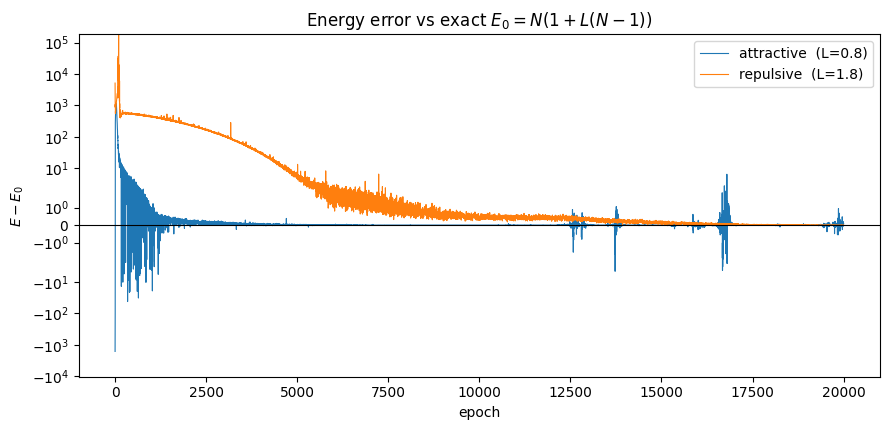

attractive   L=0.8: final E=   726.0840  exact=   726.0000  rel err=1.16e-04
repulsive    L=1.8: final E=  1595.9984  exact=  1596.0000  rel err=9.94e-07


In [25]:
fig, ax = plt.subplots(figsize=(9, 4.4))
for name, L in REGIMES.items():
    e = np.array([float(s.energy) for s in results[name].history])
    ax.plot(e - E_exact(L), lw=0.8, label=f'{name}  (L={L})')
ax.axhline(0, color='k', lw=0.8)
ax.set(xlabel='epoch', ylabel=r'$E - E_0$', yscale='symlog',
       title=r'Energy error vs exact $E_0 = N(1+L(N-1))$')
ax.legend(); plt.tight_layout(); plt.show()

for name, L in REGIMES.items():
    e = np.array([float(s.energy) for s in results[name].history])
    print(f"{name:12s} L={L:.1f}: final E={e[-1]:11.4f}  exact={E_exact(L):11.4f}  "
          f"rel err={abs(e[-1] - E_exact(L)) / E_exact(L):.2e}")

## 5. The mathematics — every formula used in this notebook

Nothing below is asserted without a derivation. Section numbers in brackets say where each
result is used.

---

### 5.1 The model and its exact ground state

Convention $\hbar^2/m = 1$ (**not** $\hbar^2/2m=1$ — this is where the stray factors of 2 come
from):

$$H \;=\; -\sum_{i=1}^{N}\partial_i^2 \;+\; \sum_i x_i^2 \;+\; 2L(L-1)\sum_{i<j}\frac{1}{(x_i-x_j)^2}$$

$$\psi_0 \;=\; \prod_{i<j}|x_i-x_j|^{L}\;e^{-\frac12\sum_i x_i^2},
\qquad
E_0 \;=\; N\bigl(1+L(N-1)\bigr)$$

**Check at $N=1$:** $H=-\partial^2+x^2$, $\psi_0=e^{-x^2/2}$. Then
$-\partial^2\psi_0 = -(x^2-1)\psi_0$, so $H\psi_0 = (1-x^2+x^2)\psi_0 = 1\cdot\psi_0$, and
$E_0 = N(1+L\cdot 0) = 1$. ✓

**Sign of the interaction.** The coupling is $g=2L(L-1)$:

$$0<L<1 \Rightarrow g<0 \ \text{(attractive)},\qquad
L=1 \Rightarrow g=0 \ \text{(free / Tonks)},\qquad
L>1 \Rightarrow g>0 \ \text{(repulsive)}$$

This notebook uses $L=0.8$ ($g=-0.32$) and $L=1.8$ ($g=+2.88$).

---

### 5.2 Why the correlation hole exists for **every** $L>0$  [§8]

$$|\psi_0|^2 \;=\; \prod_{i<j}|x_i-x_j|^{2L}\;e^{-\sum_i x_i^2}$$

Take two particles to coincidence, $x_1\to x_2$, holding all others fixed. Every factor of that
product is smooth and nonzero at $x_1=x_2$ **except one**: $|x_1-x_2|^{2L}$. Therefore

$$\boxed{\;g(\Delta)\;\sim\;\Delta^{2L}\quad\text{as }\Delta\to 0\;}$$

The exponent is $2L$, which is **positive in both regimes**. The sign of $2L(L-1)$ does not
appear. So:

- $L=0.8$: $g\sim\Delta^{1.6}$ — a **soft** hole, but still $g(0)=0$;
- $L=1.8$: $g\sim\Delta^{3.6}$ — a **hard** hole.

An attractive interaction does *not* produce a peak on the diagonal. The hole is a property of
the Jastrow exponent in $\psi_0$, not of the sign of the potential. This is the single most
important statement in the notebook.

---

### 5.3 The density profile: $R=\sqrt{2LN}$ and $\mathrm{rms}=R/2$  [§2]

$|\psi_0|^2$ is the Gaussian $\beta$-ensemble with $\beta=2L$. Writing
$|\psi_0|^2=e^{-\mathcal{E}}$, the energy functional of a density $\rho$ with $\int\rho=N$ is

$$\mathcal{E}[\rho]\;=\;\int x^2\rho(x)\,dx \;-\; L\iint \rho(x)\rho(y)\log|x-y|\,dx\,dy$$

Stationarity on the support gives $x^2 - 2L\!\int\rho(y)\log|x-y|dy = \text{const}$; differentiating,

$$2x \;=\; 2L\;\mathrm{PV}\!\int\frac{\rho(y)}{x-y}\,dy$$

The semicircle $\rho(x)=\dfrac{2N}{\pi R^2}\sqrt{R^2-x^2}$ has Hilbert transform
$\mathrm{PV}\!\int\frac{\rho(y)}{x-y}dy=\frac{2N}{R^2}x$ for $|x|<R$, so
$2x = 2L\cdot\frac{2N}{R^2}x$, giving

$$\boxed{\;R=\sqrt{2LN}\;}\qquad (R\approx 6.93 \text{ at } L=0.8,\quad R\approx 10.39 \text{ at } L=1.8)$$

**Second moment.** With $x=R\sin\theta$,

$$\langle x^2\rangle=\frac{\int_{-R}^{R}x^2\sqrt{R^2-x^2}\,dx}{\int_{-R}^{R}\sqrt{R^2-x^2}\,dx}
=\frac{R^4\,(\pi/8)}{R^2\,(\pi/2)}=\frac{R^2}{4}
\qquad\Longrightarrow\qquad
\boxed{\;\mathrm{rms}=\frac{R}{2}=\frac{\sqrt{2LN}}{2}\;}$$

This is the target in `equilibration_report`, and the width used to seed walkers in
`sample_equilibrated`. It is why a cold start fails: the default walkers sit at width $\sim 1$
while the cloud needs width $3.46$ ($L=0.8$) or $5.20$ ($L=1.8$), and MH has to transport them
there one small step at a time.

**Mean spacing.** `spacing()` returns the *nominal* value

$$a \;=\; \frac{2R}{N}$$

i.e. the spacing of $N$ particles spread uniformly over $[-R,R]$. The true spacing at the cloud
centre is $1/\rho(0)=\pi R/(2N)\approx 1.57R/N$, about $21\%$ smaller. $a$ is used only as a
**unit of length**, so this discrepancy shifts where curves saturate in $\Delta/a$ but has
**no effect on any fitted exponent**.

**Why the 0.995 quantile in `cloud_edge`.** $\max|x|$ is an extreme-value statistic driven by
the single most extreme walker and fluctuates strongly; the semicircle edge is also smeared at
finite $N$. The 0.995 quantile is a stable estimator of the same scale.

---

### 5.4 Pair correlation: definitions and normalisations  [§7]

One- and two-body densities, normalised to particle and ordered-pair counts:

$$\int\rho_1(x)\,dx = N,\qquad \iint\rho_2(x,x')\,dx\,dx' = N(N-1)$$

$$g(x,x')\;=\;\frac{\rho_2(x,x')}{\rho_1(x)\,\rho_1(x')}$$

**Uncorrelated limit.** If the particles were independent with single-particle pdf $p$, then
$\rho_1=Np$ and $\rho_2=N(N-1)p(x)p(x')$, so

$$g \;=\; \frac{N(N-1)\,p\,p}{N^2\,p\,p}\;=\;\frac{N-1}{N}$$

— exactly $29/30\approx 0.967$ here, **not** 1. That is the correct baseline for the flat region
of the maps.

**Estimators** (`qvarnet.estimators.kernels`, sampling $M$ configurations from $|\psi|^2$):

$$\rho_1 \leftarrow \frac{\text{hist}}{M\,dx}
\qquad\Longrightarrow\qquad \int\rho_1 = \frac{MN}{M}=N \ \checkmark$$

$$\rho_2 \leftarrow \frac{\text{hist2d}+\text{hist2d}^{T}}{M\,dx^2}
\qquad\Longrightarrow\qquad \iint\rho_2 = \frac{2M\cdot\frac{N(N-1)}{2}}{M}=N(N-1) \ \checkmark$$

The transpose is added because `triu_indices` enumerates each unordered pair once, while
$\rho_2$ is defined over *ordered* pairs; histogramming $(x_j,x_i)$ is the mirror of $(x_i,x_j)$.

Bins are set to `nan` where the expected uncorrelated count

$$n_{\rm exp}(x,x') \;=\; \rho_1(x)\rho_1(x')\,\frac{N-1}{N}\,M\,dx^2$$

falls below 5, so empty tails do not produce a spuriously large ratio of two small numbers.

---

### 5.5 The bin-width artifact — why `g_grid` fixes $dx$ in units of $a$  [§7]

A histogram reports a **bin average**, not a point value. Near the diagonal, with
$g(u)\simeq C u^{2L}$,

$$\bar g(0,0)\;=\;\frac{1}{dx}\int_0^{dx} C\,u^{2L}\,du\;=\;\frac{C\,dx^{2L}}{2L+1}
\qquad\Longrightarrow\qquad \boxed{\;\bar g(0,0)\ \propto\ dx^{\,2L}\;}$$

The reported depth depends on the bin width **raised to the very exponent being measured**, and
differently for each $L$. The two regimes have different cloud sizes, so a grid with a fixed
*number of points* gives them different $dx$ — and the artifact partly cancels the real
difference. Measured on identical samples:

| grid | $\bar g(0,0)$, $L=0.8$ | $\bar g(0,0)$, $L=1.8$ | ratio |
|---|---|---|---|
| fixed 81 points | 0.175 | 0.120 | 1.5 |
| fixed $dx=a/4$  | 0.089 | 0.037 | 2.4 |

`g_grid(samples, pts_per_spacing=4)` therefore sets $dx=a/4$ and derives the point count from
$R$, so both panels are binned identically in physical units.

---

### 5.6 From $g(x_1,x_2)$ to a function of separation — what is and is not legitimate  [§8]

**The objection, stated properly.** $g(r)$ as a function of separation *alone* is a
**homogeneous**-system object. Under PBC the density $\rho=N/V$ is constant and translation
invariance is exact, so

$$g(r)\;=\;\frac{V}{N(N-1)}\Bigl\langle\sum_{i\neq j}\delta\bigl(r-(x_i-x_j)\bigr)\Bigr\rangle$$

is well defined: the centre-of-mass integral is carried out exactly and contributes a factor $V$.
**In a harmonic trap none of that holds.** There is no translation invariance, $\rho(x)$ is not
constant, and there is *no* $g(r)$. The honest object is the two-coordinate $g(x_1,x_2)$ — which
is precisely what §7 plots, with no approximation.

**The change of variables is exact** (Jacobian 1):

$$c=\tfrac12(x_i+x_j),\qquad \Delta=x_i-x_j$$

$$n(\Delta)\;=\;\int dc\;\rho(c+\tfrac\Delta2)\,\rho(c-\tfrac\Delta2)\;
g\bigl(c+\tfrac\Delta2,\,c-\tfrac\Delta2\bigr)$$

Under PBC the integrand does not depend on $c$ and the integral collapses to $V\rho^2 g(\Delta)$.
In a trap it does not, and $n(\Delta)$ is **not** proportional to any single $g(\Delta)$.

**What survives the inhomogeneity: the exponent.** In the coalescence limit,

$$g(x_1,x_2)\;\xrightarrow[\Delta\to0]{}\;C(c)\,\Delta^{2L}$$

The prefactor $C$ depends on position, but the **exponent does not**: the factor
$|x_1-x_2|^{2L}$ sits in $\psi_0$ regardless of where in the trap the pair is (§5.2). Hence

$$\boxed{\;n(\Delta)\;\xrightarrow[\Delta\to0]{}\;\Delta^{2L}\int dc\;\rho(c)^2\,C(c)
\;=\;\text{const}\times\Delta^{2L}\;}$$

The $c$-integral contributes a **$\Delta$-independent constant, however inhomogeneous the system
is**. So the exponent requires no homogeneity assumption at all — only the local structure of
$\psi_0$ at coalescence.

**What §8 actually plots.** Define the windowed, large-$\Delta$-normalised pair-separation
distribution

$$\tilde g(\Delta)\;\equiv\;\frac{n_W(\Delta)}{n_W(\Delta\to\text{large})}$$

This is **not** $g(r)$ — it coincides with it only for a homogeneous system. What is exact is
$\tilde g(\Delta)\propto\Delta^{2L}$ as $\Delta\to0$, and that is the only property §8 uses.

In **one dimension** there is no measure factor, so $\mathrm{pdf}(\Delta)\propto\tilde g(\Delta)$.
(In $d$ dimensions it would be $\mathrm{pdf}\propto\Delta^{d-1}\tilde g$ — relevant if this is
ever ported to 3D.)

**So what is the centre window for?** Not correctness. Measured sensitivity of the fitted $p$
(cached exact samples; the $L=1.8$ set is deliberately under-mixed, see §5.8, so read the
*variation across rows*, not the absolute value):

| `centre_frac` | window | pairs kept | $p$, $L=0.8$ ($2L=1.6$) | $p$, $L=1.8$ ($2L=3.6$) |
|---|---|---|---|---|
| 0.05 | $\pm0.75a$ | 15k–30k | 1.55 | 2.86 |
| 0.10 | $\pm1.50a$ | 28k–61k | 1.59 | 2.68 |
| **0.15** | $\pm2.25a$ | 41k–91k | **1.51** | **2.56** |
| 0.20 | $\pm3.00a$ | 53k–121k | 1.53 | 2.56 |
| 0.30 | $\pm4.50a$ | 75k–174k | 1.55 | 2.55 |
| 0.50 | $\pm7.50a$ | 106k–261k | 1.54 | 2.52 |
| 1.00 | whole cloud | 123k–329k | 1.53 | 2.48 |

The exponent is stable to $\sim5\%$ **even with no window at all** — exactly as the boxed result
above predicts. The window's real purpose is narrower: the fit range $[0.02a,\,0.25a]$ is
expressed in the *global* $a=2R/N$, but the *local* spacing $1/\rho(c)$ grows toward the cloud
edge where $\rho$ falls. Pairs from the outer region therefore leave their power-law region
earlier in units of the global $a$, and including them drags the fit slightly low
($2.56\to2.48$). `centre_frac=0.15` sits on the plateau — 0.15, 0.20 and 0.30 agree to $0.01$ —
while retaining enough pairs.

Finally, consistency of the window with the fit range: a retained pair has
$\Delta\le0.25a$, so each particle sits within $\Delta/2\le0.125a$ of the midpoint — about
$5.6\%$ of the window half-width $0.15R=2.25a$. Both particles of every fitted pair are therefore
well inside the window.

---

### 5.7 `exponent_cdf` — the binning-free exponent fit  [§8]

Assume $g(\Delta)=C\Delta^{p}$ for $\Delta\ll a$. The cumulative distribution of pair
separations is then

$$F(\Delta)\;=\;\int_0^{\Delta}\mathrm{pdf}(u)\,du\;\propto\;\int_0^\Delta u^{p}du\;\propto\;\Delta^{\,p+1}$$

$$\boxed{\;\log F(\Delta) \;=\; (p+1)\log\Delta \;+\; \text{const}\;}$$

so a straight-line fit of $\log F$ against $\log\Delta$ returns slope $p+1$, and the code
subtracts 1. $F$ is estimated by the **empirical CDF**: sort the $M$ separations ascending and
set $F_k = k/M$.

**Why not fit the histogram of $g$ directly?** At $2L=3.6$ the small-$\Delta$ bins are nearly
empty; zero and near-zero counts make $\log g$ undefined or wildly noisy, and the fit is badly
biased. A binned fit on the same data returned $p=2.37$ for a true $3.6$. The CDF has no bin
width to choose, no empty bins, is monotone (hence smooth), and uses every data point.

**The fit window $[0.02\,a,\;0.25\,a]$.**

- *Upper bound:* the power law holds only for $\Delta\ll a$; beyond that $g$ bends over toward
  $(N-1)/N$. Fitting too wide destroys the estimate — window $[0.05a,0.35a]$ returned $p=0.43$
  against a true $1.6$.
- *Lower bound:* below $\sim 0.02a$ the statistics thin out, and the model itself is softened
  ($|x_i-x_j|+10^{-6}$ in `CalogeroSutherlandAnalyticModel`, `EPS` in the Hamiltonian), so the
  true power law is cut off at very small $\Delta$ anyway.

**Validation** on the exact $\psi_0$ with the notebook's sampling settings:

| $L$ | fitted $p$ | exact $2L$ |
|---|---|---|
| 0.8 | 1.63 | 1.6 |
| 1.8 | 3.69 | 3.6 |

---

### 5.8 Why the fitted exponent is also a **mixing diagnostic**  [§2, §8]

Walkers are initialised as independent Gaussians — i.e. uncorrelated, $g\equiv 1$, $p=0$.
Equilibration is precisely the process of the Jastrow factor **expelling** close pairs until the
$\Delta^{2L}$ hole is fully carved. An incompletely mixed chain therefore retains an *excess* of
close pairs, and the measured exponent sits somewhere in

$$0 \;\le\; p_{\rm measured} \;<\; 2L$$

The bias is **always downward** — never above $2L$. Measured at $L=1.8$ (true $3.6$):

| chain | fitted $p$ |
|---|---|
| 600 steps  | 2.50 |
| 3000 steps | 3.52 |
| 3200 steps, last 200 kept | 3.69 |

**The crucial point:** at 600 steps the `rms` check in §2 **already passed** ($5.17$ vs target
$5.20$) while $p$ was still $2.50$. The bulk cloud size equilibrates far faster than the
short-range structure, so `rms` alone would have certified a chain that was badly wrong for
$g$. Both checks are needed.

---

### 5.9 The zero-variance principle  [§2b]

The local energy of a trial state is

$$E_{\rm loc}(x)\;=\;\frac{\hat H\psi(x)}{\psi(x)}$$

For an exact eigenstate, $\hat H\psi_0 = E_0\psi_0$, hence

$$\boxed{\;E_{\rm loc}(x)=E_0 \ \ \text{for every }x
\qquad\Longrightarrow\qquad \mathrm{Var}\bigl[E_{\rm loc}\bigr]=0\;}$$

This identity holds **pointwise**, so it does not depend on the sampling being converged at all.
That makes §2b the strongest and cleanest test in the notebook: it isolates *"is the physics
coded correctly"* from *"has the chain mixed"*. Passing it confirms that the analytic model's
$\log\psi$, the kinetic operator (including the factor of 2 below), the $2L(L-1)$ potential
coefficient and $E_0=N(1+L(N-1))$ are all mutually consistent. Any convention error would make
$E_{\rm loc}$ vary with $x$.

Measured: $\mathrm{std}(E_{\rm loc}) = 5.5\times10^{-2}$ against $E_0=726$, and
$1.0\times10^{-3}$ against $E_0=1596$ — relative $7\times10^{-5}$ and $6\times10^{-7}$.

---

### 5.10 Kinetic energy in log space, and the factor of 2

All qvarnet models output $u \equiv \log|\psi|$. With $\psi=e^{u}$,

$$\nabla\psi = \psi\,\nabla u,\qquad
\nabla^2\psi = \psi\bigl(\nabla^2 u + |\nabla u|^2\bigr)
\qquad\Longrightarrow\qquad
\frac{\nabla^2\psi}{\psi} = \nabla^2 u + |\nabla u|^2$$

For the standard convention $H=-\tfrac12\nabla^2+V$ this gives qvarnet's `kinetic_log`:

$$T_{\rm loc} = -\tfrac12\Bigl(\nabla^2\log|\psi| + \bigl|\nabla\log|\psi|\bigr|^2\Bigr)$$

The CS Hamiltonian above uses $-\sum_i\partial_i^2$, i.e. twice that operator — which is exactly
the factor 2 in `CalogeroSutherlandHamiltonian.kinetic_local_energy`, and why
$E_0=N(1+L(N-1))$ rather than half of it.

---

### 5.11 Memory: why `cap()` and `SAMPLE_BLOCK` exist

**Host.** Every pair estimator forms arrays of shape $\bigl(M,\;\tfrac{N(N-1)}{2}\bigr)$. At
$N=30$ that is 435 numbers per configuration, and there are several temporaries
(`xi`, `xj`, `ctr`, `d`). With all $M=819{,}200$ retained configurations that is
$3.6\times10^{8}$ entries per array — several GB each. `cap()` subsamples to $M\le 300{,}000$.
Walkers are **exchangeable** and independent across chains, so a uniformly random subset is
unbiased; it costs variance only.

**Device.** The sampler holds the full trajectory $(n_{\rm chains}, n_{\rm steps}, \mathrm{dof})$.
At $4096\times3200\times30$ float32 that is $\approx 1.6$ GB in one allocation; `SAMPLE_BLOCK=512`
splits it into blocks so peak device memory scales with the block, not the total.

**Retention.** Consecutive MH steps are strongly correlated, so retained configurations are worth
far less than independent ones. A long discard with few kept steps ($3000$ discarded, $200$ kept)
gives the same effective statistics as a short discard with many, at $15\times$ less memory.

---

### 5.12 What is **not** computed here

No error bars are placed on $g$ or on the fitted $p$. The samples are strongly autocorrelated in
the step direction, so a naive $\sigma/\sqrt{M}$ would be far too small. A correct error bar
needs Flyvbjerg-Petersen blocking (`qvarnet.estimators.kernels.blocking_error`) applied
**per chain**, or the integrated autocorrelation time $\tau$ from
`qvarnet.diagnostics.mcmc.iat_geyer` with $M_{\rm eff}=M/(2\tau)$. The agreement of the fitted
exponents with $2L$ to within $\sim3\%$ is used here as the accuracy statement instead.

## 6. Pair-correlation helpers

Everything here is in units of the **mean interparticle spacing** $a = 2R/N$, so the two
couplings are directly comparable despite their different cloud sizes.

`exponent_cdf` fits the exponent without binning: if $g(\Delta)\sim\Delta^{p}$ at short range,
the cumulative distribution of pair separations goes as $F(\Delta)\sim\Delta^{p+1}$, so a
straight-line fit of $\log F$ vs $\log\Delta$ gives $p$. It doubles as a **sampling diagnostic**:
a fitted $p$ well *below* $2L$ means the chain is under-mixed at short separations (not visiting
close pairs often enough), not that the physics is different.

In [26]:
MAX_ROWS = 300_000   # cap on configurations per estimator (memory guard)


def cap(samples, max_rows=MAX_ROWS, seed=0):
    """Subsample configurations so the pair arrays stay bounded.

    Every pair estimator builds an (M, N(N-1)/2) array -- at N=30 that is 435
    numbers per configuration, so M must be capped or the host runs out of RAM.
    Walkers are exchangeable, so a random subset costs nothing but variance.
    """
    s = np.asarray(samples)
    if s.shape[0] <= max_rows:
        return s
    idx = np.random.default_rng(seed).choice(s.shape[0], max_rows, replace=False)
    return s[np.sort(idx)]


def cloud_edge(samples):
    """Robust outer edge of the walker cloud (0.995 quantile of |x|)."""
    return float(np.quantile(np.abs(np.asarray(samples)), 0.995))


def spacing(samples, n_particles=N):
    """Mean interparticle spacing a = 2R/N -- the natural length unit."""
    return 2 * cloud_edge(samples) / n_particles


def g_grid(samples, n_particles=N, pts_per_spacing=4):
    """Grid with bin width = a / pts_per_spacing.

    Fixed bin width *in units of a* is what makes the L=0.8 and L=1.8 maps comparable.
    A fixed number of points over different cloud sizes would give different bin widths,
    and g(0,0) is a bin average of Delta^{2L} -- so bin width alone would shift it.
    """
    R  = cloud_edge(samples)
    dx = spacing(samples, n_particles) / pts_per_spacing
    npts = int(2 * R / dx) // 2 * 2 + 1        # odd -> one bin centred on 0
    return np.linspace(-R, R, npts)


def pair_separations(samples, n_particles=N, centre_frac=0.15):
    """|x_i - x_j| for pairs whose midpoint sits in the flat central region."""
    s = cap(samples)
    i, j = np.triu_indices(n_particles, k=1)
    xi, xj = s[:, i], s[:, j]
    ctr, d = 0.5 * (xi + xj), np.abs(xi - xj)
    return d[np.abs(ctr) < centre_frac * cloud_edge(s)]


def exponent_cdf(samples, n_particles=N, lo=0.02, hi=0.25):
    """Binning-free fit of p in g(Delta) ~ Delta^p.  Expect p = 2L."""
    d = np.sort(pair_separations(samples, n_particles))
    a = spacing(samples, n_particles)
    F = np.arange(1, d.size + 1) / d.size
    m = (d > lo * a) & (d < hi * a)
    if m.sum() < 20:
        return np.nan
    return float(np.polyfit(np.log(d[m]), np.log(F[m]), 1)[0]) - 1.0


def g_of_delta(samples, n_particles=N, n_bins=120, span=3.0):
    """g(Delta) normalised to 1 at large separation. Returns (Delta/a, g, a)."""
    d = pair_separations(samples, n_particles)
    a = spacing(samples, n_particles)
    edges = np.linspace(0.0, span * a, n_bins + 1)
    h, _ = np.histogram(d, bins=edges)
    dc = 0.5 * (edges[:-1] + edges[1:])
    g = h / (edges[1] - edges[0])
    g = g / np.mean(g[dc > 0.7 * span * a])
    return dc / a, g, a

## 7. $g(x_1,x_2)$ maps — exact vs trained, both regimes

**Log** colour scale. On a linear 0–1.2 scale every panel is an identical dark diagonal line;
the log scale is what makes the difference in hole depth visible.

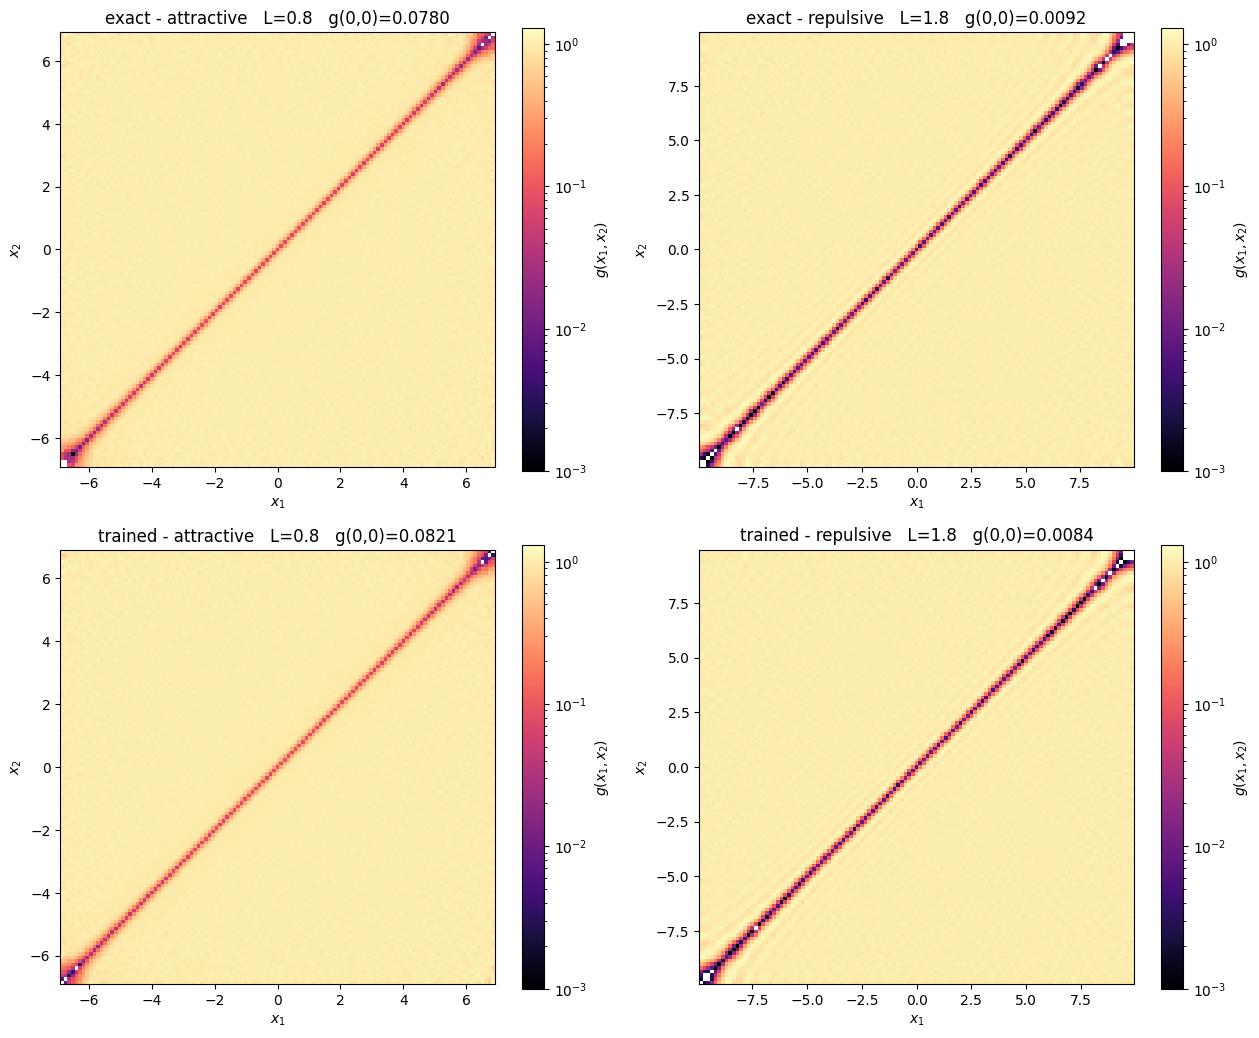

In [27]:
fig, axes = plt.subplots(2, len(REGIMES), figsize=(6.4 * len(REGIMES), 10.5))
norm = LogNorm(vmin=1e-3, vmax=1.3)

for col, (name, L) in enumerate(REGIMES.items()):
    for row, (label, store) in enumerate((('exact', exact), ('trained', trained))):
        wf   = store[name]
        s    = cap(wf.samples)                    # memory guard, see helpers above
        grid = g_grid(s)
        grid, g2 = wf.pair_correlation_grid(grid, samples=s)
        mid  = len(grid) // 2
        ax   = axes[row, col]
        im = ax.pcolormesh(grid, grid, g2.T, shading='auto', cmap='magma', norm=norm)
        fig.colorbar(im, ax=ax, label=r'$g(x_1,x_2)$')
        ax.set(xlabel=r'$x_1$', ylabel=r'$x_2$', aspect='equal',
               title=f'{label} - {name}   L={L}   g(0,0)={g2[mid, mid]:.4f}')
plt.tight_layout(); plt.show()

## 8. $g(\Delta)$ and the exponent — the sharp signature

Left: the windowed pair-separation distribution $\tilde g(\Delta)$ (§5.6) in units of $a$.
Right: the same on log-log, where the short-range behaviour is a straight line of slope $2L$
(dotted = the exact power law, anchored to the data).

$\tilde g$ is **not** $g(r)$ — in a trap there is no $g(r)$, only $g(x_1,x_2)$ (plotted in §7).
What is exact, and independent of the trap's inhomogeneity, is $\tilde g(\Delta)\sim\Delta^{2L}$
as $\Delta\to0$. That short-range slope is the only thing read off here; see §5.6.

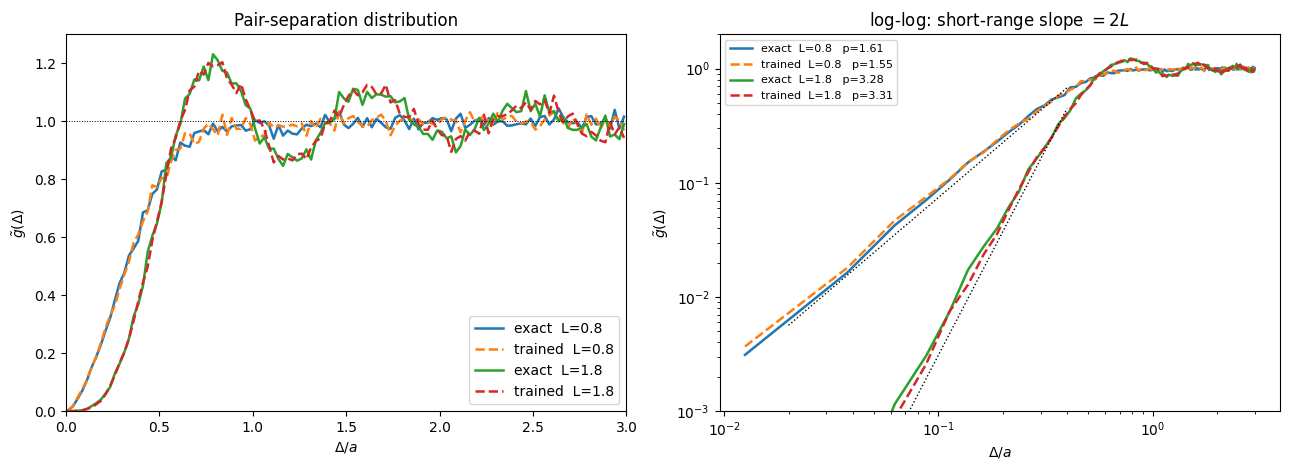


regime           L    wavefn  fitted p     2L  verdict
attractive    0.80     exact      1.61   1.60  ok
attractive    0.80   trained      1.55   1.60  ok
repulsive     1.80     exact      3.28   3.60  ok
repulsive     1.80   trained      3.31   3.60  ok


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
rows = []

for name, L in REGIMES.items():
    for label, store, ls in (('exact', exact, '-'), ('trained', trained, '--')):
        s = store[name].samples
        x, g, a = g_of_delta(s)
        p = exponent_cdf(s)
        rows.append((name, L, label, p, 2 * L))
        axes[0].plot(x, g, ls, lw=1.8, label=f'{label}  L={L}')
        m = g > 0
        axes[1].loglog(x[m], g[m], ls, lw=1.8, label=f'{label}  L={L}   p={p:.2f}')

for name, L in REGIMES.items():                 # exact power-law references, anchored to data
    x, g, a = g_of_delta(exact[name].samples)
    xs = np.logspace(-1.7, -0.4, 40)
    j  = int(np.argmin(np.abs(x - 0.25)))       # anchor inside the fitted window
    c  = g[j] / 0.25 ** (2 * L) if g[j] > 0 else 1.0
    axes[1].loglog(xs, c * xs ** (2 * L), 'k:', lw=1.0)

axes[0].axhline(1.0, color='k', lw=0.7, ls=':')
axes[0].set(xlabel=r'$\Delta / a$', ylabel=r'$\tilde g(\Delta)$', xlim=(0, 3), ylim=(0, 1.3),
            title='Pair-separation distribution')
axes[0].legend()
axes[1].set(xlabel=r'$\Delta / a$', ylabel=r'$\tilde g(\Delta)$', ylim=(1e-3, 2),
            title=r'log-log: short-range slope $= 2L$')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\n{'regime':12s} {'L':>5s} {'wavefn':>9s} {'fitted p':>9s} {'2L':>6s}  verdict")
for name, L, label, p, tgt in rows:
    v = 'ok' if abs(p - tgt) < 0.35 * tgt else 'low -> under-mixed at short range'
    print(f"{name:12s} {L:5.2f} {label:>9s} {p:9.2f} {tgt:6.2f}  {v}")

## Notes — what to look for

1. **Both regimes have a hole.** $g(0,0)\to 0$ at $L=0.8$ *and* $L=1.8$. What differs is the
   depth and the exponent ($\Delta^{1.6}$ vs $\Delta^{3.6}$). If you expected the attractive
   regime to show a *peak* on the diagonal, that expectation is wrong: the hole comes from the
   Jastrow exponent $L>0$, positive in both cases, not from the sign of $2L(L-1)$.

2. **The exponent is the diagnostic, not the picture.** Two maps that look alike can have
   $g(0,0)$ differing by more than an order of magnitude. Read section 8's fitted $p$ before
   concluding anything from section 7.

3. **`rms` vs $\sqrt{2LN}/2$ is the first thing to check.** If a cloud falls short of its
   target the chain never expanded, and $g$ will look identical at every coupling. Raise
   `SAMPLE_STEPS` / `SAMPLE_BURN`, or seed the walkers.

4. **A fitted $p$ below $2L$ means under-mixing at short range**, not different physics — the
   chain is not visiting close pairs often enough, and it is the **burn-in length** that fixes
   it. Measured on the exact $\psi_0$ at $L=1.8$ (true $2L=3.6$): a 600-step chain gives
   $p=2.50$, a 3000-step chain gives $p=3.52$. The repulsive regime needs the most, because $\Delta^{3.6}$ makes
   close pairs very rare. The `rms` check in section 2 passes long before this one does — bulk
   size equilibrates much faster than short-range structure, so **`rms` alone is not enough**.

5. **Re-run every cell after changing `REGIMES`.** `TrainedWavefunction` caches both the params
   and `wf.samples`; re-running only the plotting cell reproduces the previous figure exactly.